In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from keras import layers
from keras import models

c:\Users\Administrator\anaconda3\envs\dl\Lib\site-packages\requests\__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
(train_images, train_labels), (test_images, test_labels) = \
    tf.keras.datasets.fashion_mnist.load_data()

In [3]:
print("Train images shape:", train_images.shape)
print("Train labels shape:", train_labels.shape)

print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)

Train images shape: (60000, 28, 28)
Train labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


In [4]:
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

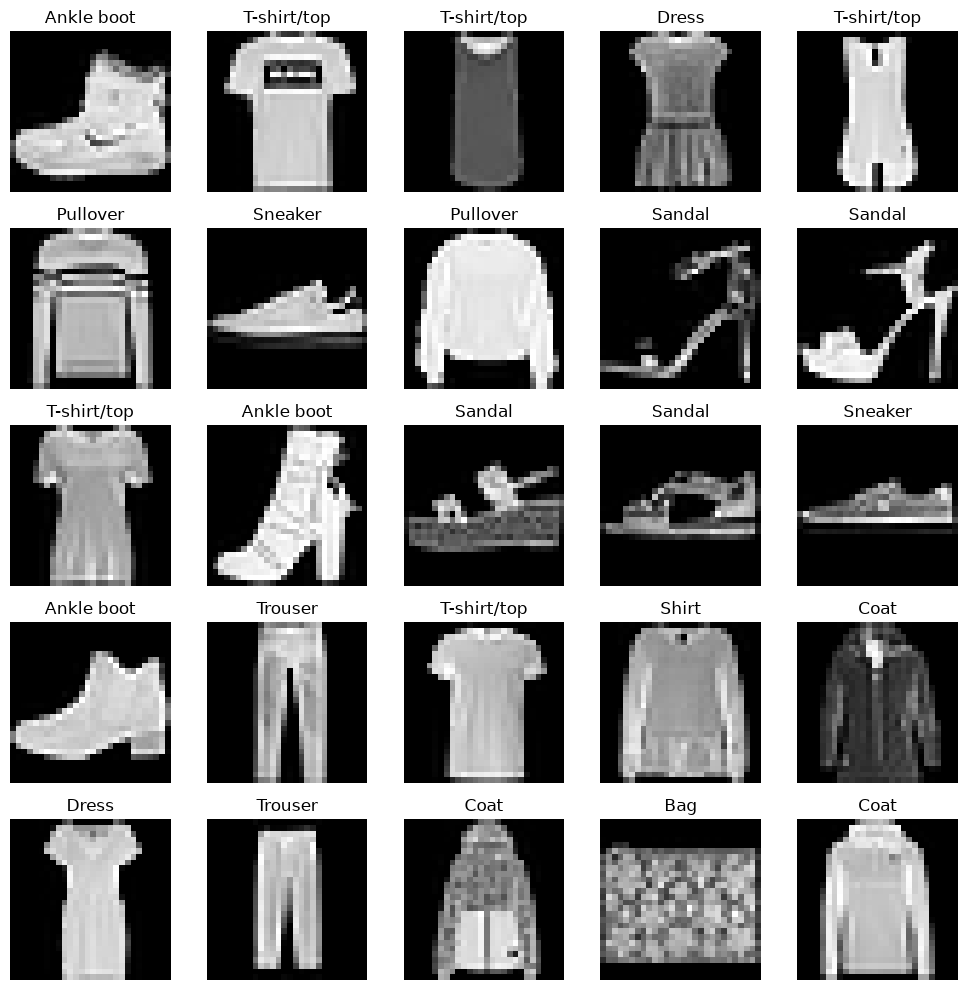

In [5]:
plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i + 1)

    plt.imshow(
        train_images[i],
        cmap='gray'
    )

    plt.title(
        class_names[train_labels[i]]
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

In [8]:
train_images = train_images[..., np.newaxis]
test_images = test_images[..., np.newaxis]

In [9]:
print(train_images.shape)
print(test_images.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [10]:
model = models.Sequential()

model.add(
    layers.Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    )
)

model.add(
    layers.MaxPooling2D(
        (2, 2)
    )
)

model.add(
    layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    )
)

model.add(
    layers.MaxPooling2D(
        (2, 2)
    )
)

model.add(
    layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    )
)

c:\Users\Administrator\anaconda3\envs\dl\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.add(
    layers.Flatten()
)

model.add(
    layers.Dense(
        64,
        activation='relu'
    )
)

model.add(
    layers.Dense(
        10,
        activation='softmax'
    )
)

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [15]:
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_model.keras',
    monitor='val_loss',
    save_best_only=True
)

In [16]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

In [17]:
callbacks = [
    early_stopping,
    model_checkpoint,
    reduce_lr
]

In [18]:
history = model.fit(
    train_images,
    train_labels,

    epochs=30,

    batch_size=64,

    validation_split=0.1,

    callbacks=callbacks
)

Epoch 1/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 32s 34ms/step - accuracy: 0.7944 - loss: 0.5671 - val_accuracy: 0.8632 - val_loss: 0.3742 - learning_rate: 0.0010
Epoch 2/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.8732 - loss: 0.3503 - val_accuracy: 0.8887 - val_loss: 0.3147 - learning_rate: 0.0010
Epoch 3/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.8904 - loss: 0.2998 - val_accuracy: 0.8937 - val_loss: 0.2846 - learning_rate: 0.0010
Epoch 4/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9022 - loss: 0.2667 - val_accuracy: 0.8995 - val_loss: 0.2780 - learning_rate: 0.0010
Epoch 5/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9093 - loss: 0.2440 - val_accuracy: 0.9057 - val_loss: 0.2687 - learning_rate: 0.0010
Epoch 6/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9176 - loss: 0.2236 - val_accuracy: 0.9070 - val_loss: 0.2564 - learning_rate: 0.0010
Epoch 7/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - accuracy: 0.9245 - l

In [22]:
test_loss, test_accuracy = model.evaluate(
    test_images,
    test_labels
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9159 - loss: 0.2669
Test Loss: 0.26685965061187744
Test Accuracy: 0.9158999919891357


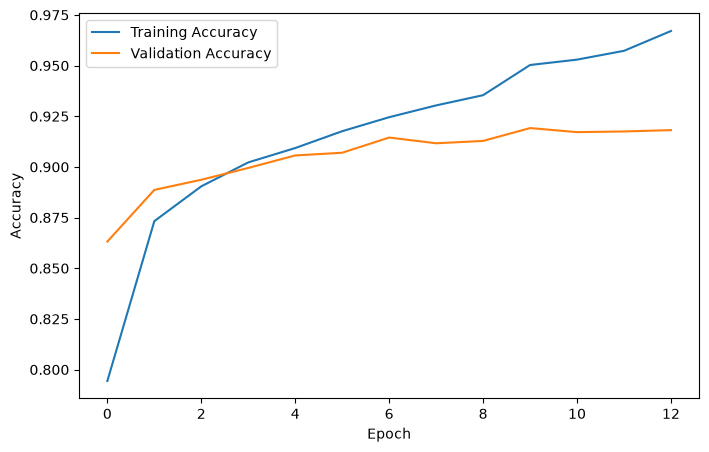

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.show()

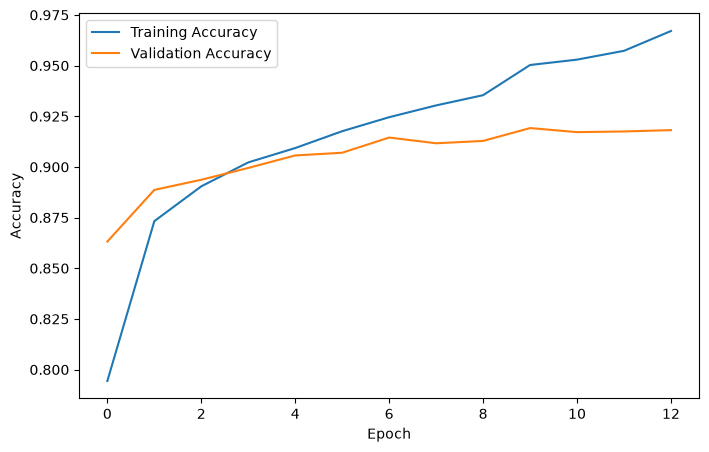

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.show()